# Clean and export: train / test / val (pre-split)

Unlike the earlier version of this notebook, the three sets are now generated
*separately* (`generate_training_test_val_sets.py`, independent Sobol samplers,
seeds 42/43/44) rather than split out of one array after the fact -- so there's
no held-out slicing to do here. This notebook cleans each set and writes what
`train_nn_emu.py` (or the manual GradientTape loop, given the Keras 3
`trainable_variables` issue) expects.

Cleaning thresholds are derived once from the training set (the largest, most
statistically stable sample) and applied identically to test and val, so a
sample isn't flagged differently depending on which file it happens to sit in.

In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

OUT_DIR = '/spiffball/cosweeney/data/training/compact_multipole_training_set/z0p5/'
ELLS = (0, 2, 4)
SETS = ('train', 'test', 'val')

data = {}
for name in SETS:
    data[name] = {
        'thetas': np.load(OUT_DIR + f'thetas_{name}.npy'),
        'xi':     np.load(OUT_DIR + f'xi_{name}.npy'),
    }
s = np.load(OUT_DIR + 's.npy')

for name in SETS:
    print(f"{name:6s}  thetas {data[name]['thetas'].shape}  xi {data[name]['xi'].shape}")

train   thetas (50000, 6)  xi (50000, 3, 156)
test    thetas (5000, 6)  xi (5000, 3, 156)
val     thetas (5000, 6)  xi (5000, 3, 156)


## 1. Inventory

Same checks as before, run per set so a problem specific to one (e.g. a bad
batch during generation) doesn't hide inside an aggregate number.

In [2]:
for name in SETS:
    xi = data[name]['xi']
    finite = np.isfinite(xi).all(axis=(1, 2))
    amp = np.abs(xi).max(axis=(1, 2))
    print(f"{name:6s}  non-finite: {(~finite).sum():5d}   amp>10: {(amp>10).sum():5d}   "
          f"amp>1e3: {(amp>1e3).sum():5d}   "
          f"amp 99.9th pct: {np.percentile(amp[finite], 99.9):.3f}")

train   non-finite:     4   amp>10:    32   amp>1e3:    22   amp 99.9th pct: 8.235
test    non-finite:     1   amp>10:     6   amp>1e3:     3   amp 99.9th pct: 14.664
val     non-finite:     1   amp>10:     3   amp>1e3:     2   amp 99.9th pct: 7.663


## 2. Flag the known failure modes

Same two signatures as before -- the collapsed-integral case (`xi_0` flat at
-1, higher multipoles ~0) and the under-resolved/noisy case. The roughness
threshold is computed **once, from train**, and reused for test/val below.

In [3]:
def flag(xi, rough_ref=None):
    xi0 = xi[:, 0]
    finite = np.isfinite(xi).all(axis=(1, 2))
    collapsed = (np.median(xi0, axis=1) < -0.5) | (np.abs(xi[:, 1]).max(axis=1) < 1e-8)
    rough = np.abs(np.diff(xi0, n=2, axis=1)).mean(axis=1) / np.abs(xi0).mean(axis=1)
    if rough_ref is None:
        rough_ref = np.median(rough[finite & ~collapsed])
    noisy = rough > 5 * rough_ref
    amp = np.abs(xi).max(axis=(1, 2))
    bad = ~finite | (amp > 10) | collapsed | noisy
    return bad, rough_ref


bad_train, rough_ref = flag(data['train']['xi'])
print(f"roughness reference (from train): {rough_ref:.5f}")

keep = {}
for name in SETS:
    bad, _ = flag(data[name]['xi'], rough_ref=rough_ref)
    keep[name] = ~bad
    print(f"{name:6s}  excluding {bad.sum():5d} of {len(bad):6d}  "
          f"({100*bad.mean():.2f}%)")

roughness reference (from train): 0.01298
train   excluding    93 of  50000  (0.19%)
test    excluding    11 of   5000  (0.22%)
val     excluding    15 of   5000  (0.30%)


If test/val show a **much** higher exclusion rate than train, that's worth
stopping on before continuing -- it would mean the independent Sobol draw for
that set landed disproportionately in a bad region (plausible with the
b2/lnAs failure band from the velocileptors investigation, since a different
seed samples that band differently by chance), and the held-out set may no
longer be representative of the same distribution as train.

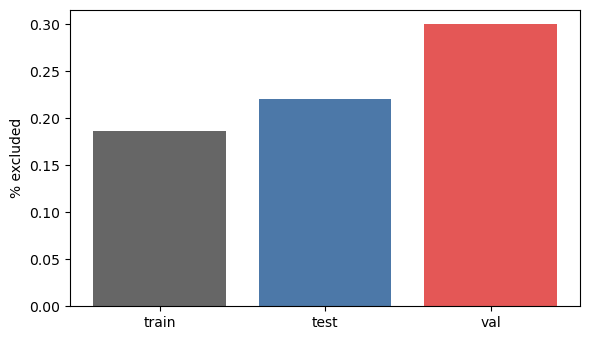

In [4]:
fig, ax = plt.subplots(figsize=(6, 3.5))
rates = [100 * (~keep[n]).mean() for n in SETS]
ax.bar(SETS, rates, color=['0.4', '#4c78a8', '#e45756'])
ax.set_ylabel('% excluded')
fig.tight_layout()

## 3. Where do the failures live? (train only, for a look at structure)

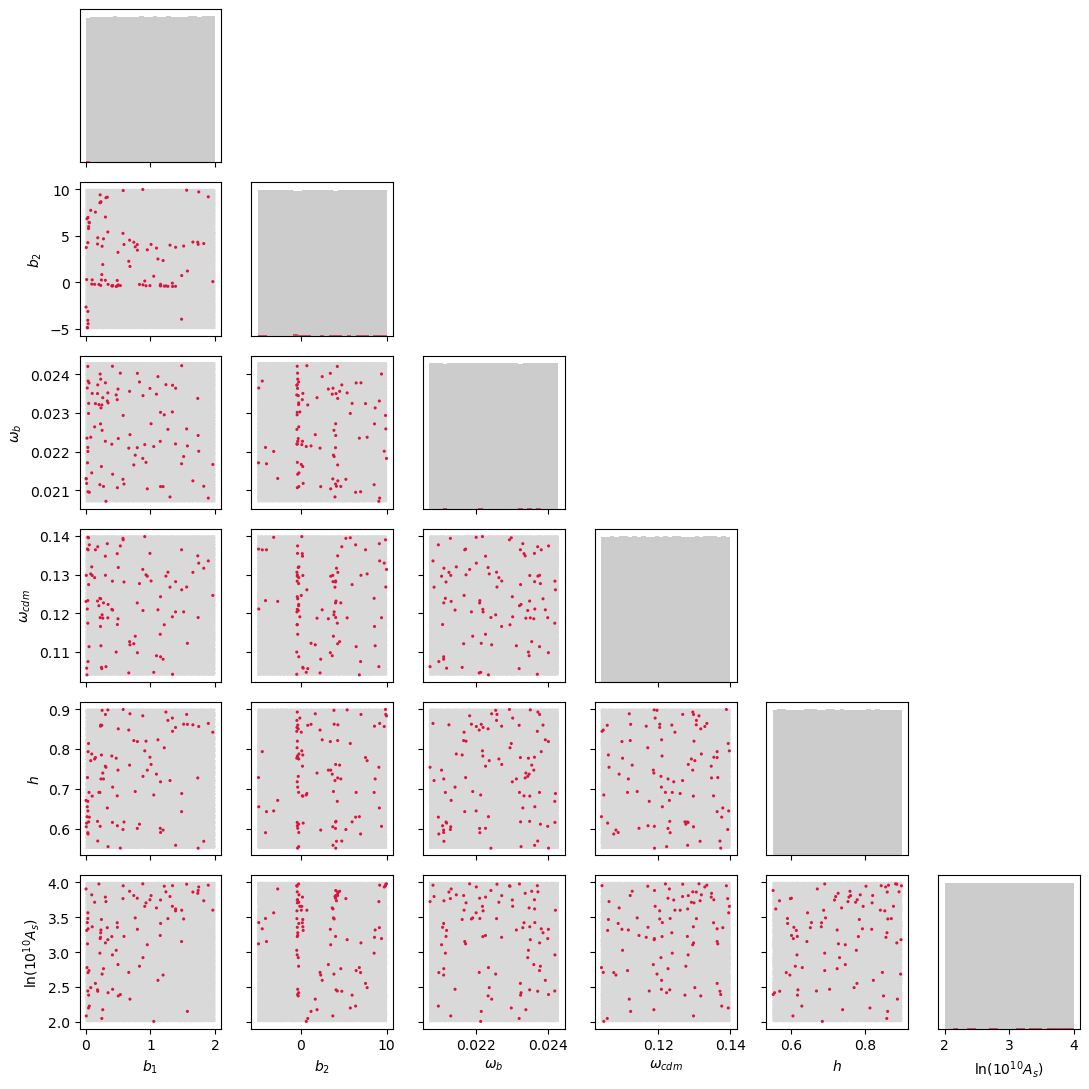

In [5]:
th, bad = data['train']['thetas'], ~keep['train']
plot_theta = th.copy()
plot_theta[:, 5] = np.log(1e10 * th[:, 5])
labels = [r'$b_1$', r'$b_2$', r'$\omega_b$', r'$\omega_{cdm}$', r'$h$',
          r'$\ln(10^{10}A_s)$']

n = plot_theta.shape[1]
fig, axes = plt.subplots(n, n, figsize=(11, 11))
for i in range(n):
    for j in range(n):
        a = axes[i, j]
        if j > i:
            a.axis('off'); continue
        if i == j:
            bins = np.linspace(plot_theta[:, i].min(), plot_theta[:, i].max(), 30)
            a.hist(plot_theta[~bad, i], bins=bins, color='0.8')
            a.hist(plot_theta[bad, i], bins=bins, color='crimson', alpha=0.7)
            a.set_yticks([])
        else:
            a.scatter(plot_theta[~bad, j], plot_theta[~bad, i], s=1,
                      c='0.85', edgecolors='none', rasterized=True)
            a.scatter(plot_theta[bad, j], plot_theta[bad, i], s=5,
                      c='crimson', edgecolors='none', rasterized=True)
        a.set_xlabel(labels[j]) if i == n-1 else a.set_xticklabels([])
        a.set_ylabel(labels[i]) if (j == 0 and i > 0) else a.set_yticklabels([])
fig.tight_layout()

The (b2, lnAs) band from the velocileptors edge-slope investigation should be
visible here. If a slope-based pre-screen or a wider `kmax` has since been
folded into `CompactStreamingModel`, this plot is also a direct check on
whether that fix reduced the failure rate relative to earlier runs.

## 4. Eyeball survivors vs flagged (train)

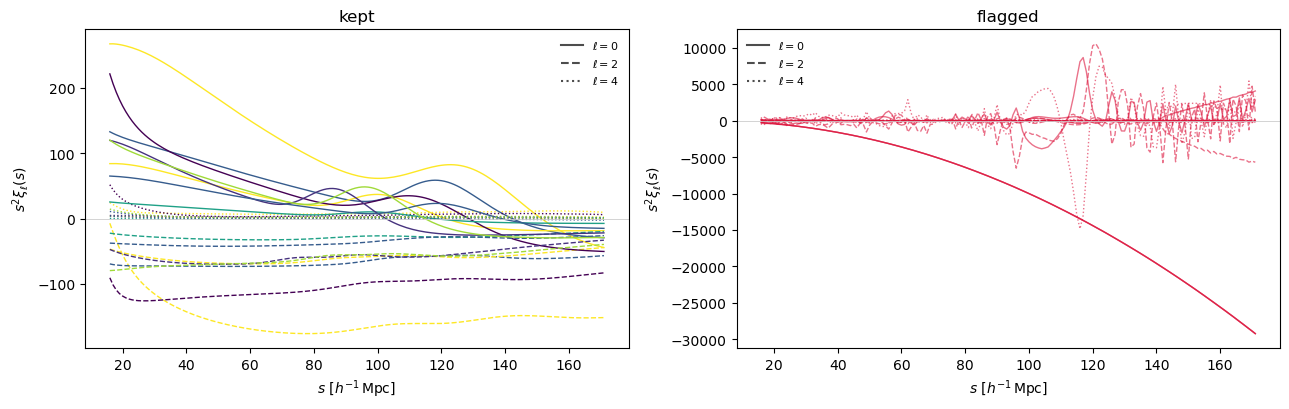

In [6]:
styles = {0: '-', 2: '--', 4: ':'}
rng = np.random.default_rng(1)
xi_tr = data['train']['xi']

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
for k in rng.choice(np.where(keep['train'])[0], 8, replace=False):
    for i, l in enumerate(ELLS):
        ax[0].plot(s, s**2 * xi_tr[k, i], styles[l], lw=1, color=plt.cm.viridis(k % 8 / 7))
ax[0].set_title('kept'); ax[0].axhline(0, c='0.8', lw=0.6)

n_bad = (~keep['train']).sum()
if n_bad:
    for k in rng.choice(np.where(~keep['train'])[0], min(8, n_bad), replace=False):
        for i, l in enumerate(ELLS):
            ax[1].plot(s, s**2 * xi_tr[k, i], styles[l], lw=1, color='crimson', alpha=0.6)
ax[1].set_title('flagged'); ax[1].axhline(0, c='0.8', lw=0.6)

for a in ax:
    a.set_xlabel(r'$s\ [h^{-1}\,\mathrm{Mpc}]$')
    a.set_ylabel(r'$s^2\xi_\ell(s)$')
    for l in ELLS:
        a.plot([], [], styles[l], c='0.3', label=rf'$\ell={l}$')
    a.legend(frameon=False, fontsize=8)
fig.tight_layout()

## 5. Export

Three separate outputs now, matching the three pre-split sets -- no slicing
needed. `params` uses the `ln(1e10 As)` coordinate the Sobol design was drawn
in, consistently across all three files, since that choice has to match at
prediction time regardless of which set is being evaluated.

`train.h5` is what `train_nn_emu.py` reads. `val` and `test` are written as
`.npz` -- `val` is meant to be passed explicitly as `validation_data` if
using the manual GradientTape training loop (the independently-sampled
validation set is preferable to `train_emu`'s internal random 80/20 split of
train, now that a real held-out val set exists). `test` stays untouched by
any training step, for final reporting only.

In [7]:
def to_params(thetas):
    p = thetas.copy()
    p[:, 5] = np.log(1e10 * thetas[:, 5])
    return p


with h5py.File(OUT_DIR + 'train.h5', 'w') as f:
    th, xi = data['train']['thetas'][keep['train']], data['train']['xi'][keep['train']]
    f.create_dataset('params', data=to_params(th).astype('float64'))
    for i, l in enumerate(ELLS):
        f.create_dataset(f'xi{l}', data=xi[:, i].astype('float64'))
    f.create_dataset('s', data=s)
    f.attrs['param_names'] = ['b1', 'b2', 'omega_b', 'omega_cdm', 'h', 'lnAs_e10']
print(f"train.h5: {keep['train'].sum()} samples")

for name in ('val', 'test'):
    th, xi = data[name]['thetas'][keep[name]], data[name]['xi'][keep[name]]
    np.savez(OUT_DIR + f'{name}.npz', params=to_params(th), xi=xi, s=s)
    print(f"{name}.npz: {keep[name].sum()} samples")

train.h5: 49907 samples
val.npz: 4985 samples
test.npz: 4989 samples


In [8]:
# round-trip check
with h5py.File(OUT_DIR + 'train.h5', 'r') as f:
    p, x0 = f['params'][:], f['xi0'][:]
print('train params ranges:')
for nm, col in zip(['b1', 'b2', 'ob', 'ocdm', 'h', 'lnAs'], p.T):
    print(f"  {nm:5s} [{col.min():9.4f}, {col.max():9.4f}]")
print(f"xi0 finite: {np.isfinite(x0).all()},  |xi0|max: {np.abs(x0).max():.3f}")

train params ranges:
  b1    [   0.0000,    2.0000]
  b2    [  -4.9998,    9.9998]
  ob    [   0.0207,    0.0243]
  ocdm  [   0.1040,    0.1400]
  h     [   0.5500,    0.9000]
  lnAs  [   2.0000,    4.0000]
xi0 finite: True,  |xi0|max: 9.784


## 6. Next

Given the Keras 3 `trainable_variables == 0` issue found earlier (raw
`tf.Variable`s in a plain list aren't tracked as trainable under default
Keras 3 -- fixed here via `TF_USE_LEGACY_KERAS=1`, set before any TF import),
train with either:

- `train_emu(...)` from the (legacy-Keras) `train_nn_emu.py`, reading
  `train.h5` and letting it split its own internal validation set out of
  train, **or**
- the manual `GradientTape` loop, passing `val.npz` explicitly as
  `Pval`/`Fval` -- preferred, since it's a genuinely independent sample
  rather than a random subset of train.

Either way, score the untouched `test.npz` at the end with the same
percentile-error plot used against Figure 3 of Ramirez et al. -- that
comparison is the actual point of the exercise, and `test` should never
appear in any training or model-selection step before that.